# Hotel Booking Cancellation — v2 — ensemble check (T2)

XGBoost is the reference model (AP 0.7644 ± 0.0080, notebook `v2/10`), and Random Forest was only
+0.0092 behind it. Can blending them, or stacking all four tree/neural models, beat XGBoost by more
than the fold noise? No model is refit here: every option is built from the saved out-of-fold (OOF)
probabilities in `reports/results/v2/oof/`, and scored on the same five outer folds with rule 9.1.
Anything that must be chosen (a weight, a meta-model) is chosen on the other four folds only.
`test.csv` is not opened.

In [1]:
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score

palette = ['#2B5C8F', '#E05A47', '#6A9F58', '#9C755F']
data = Path('../../data/processed/v2')
results = Path('../../reports/results/v2')

## 1. Training rows, saved folds and the manifest check

In [2]:
# the files must be the ones the v2 manifest froze; test.csv is never read here
manifest = json.load(open(data / 'manifest.json'))
for name in ['train.csv', 'cv_folds.csv']:
    digest = hashlib.sha256((data / name).read_bytes()).hexdigest()
    assert digest == manifest['files'][name], f'{name} does not match the manifest'

y_train = pd.read_csv(data / 'train.csv', usecols=['is_canceled'])['is_canceled'].to_numpy()
folds = pd.read_csv(data / 'cv_folds.csv', usecols=['row_id', 'outer_fold'])
assert (folds.row_id.to_numpy() == np.arange(len(y_train))).all()
print('train rows:', len(y_train), f' cancel rate {y_train.mean():.4f}')
folds.groupby('outer_fold').size().rename('rows').to_frame().T

train rows: 67974  cancel rate 0.2775


outer_fold,0,1,2,3,4
rows,13595,13594,13595,13595,13595


Both hashes match the manifest, so these are the same 67,974 rows and the same five outer folds every
model in `v2/04`–`v2/09` was scored on. Only the label column of `train.csv` is read, to check the OOF
files against it.

## 2. Out-of-fold probabilities of the four candidate models

In [3]:
models = {'xgb': 'xgboost', 'rf': 'random_forest', 'nn': 'neural_network', 'dt': 'decision_tree'}

oof = folds.assign(is_canceled=y_train)
for short, slug in models.items():
    df = pd.read_csv(results / 'oof' / f'{slug}.csv')
    assert list(df.columns) == ['row_id', 'outer_fold', 'is_canceled', 'proba']
    assert len(df) == 67974 and df.row_id.is_unique
    df = df.rename(columns={'outer_fold': f'fold_{short}', 'is_canceled': f'y_{short}', 'proba': f'p_{short}'})
    oof = oof.merge(df, on='row_id', how='left', validate='one_to_one')
    # every file must agree with the saved folds and the labels row by row
    assert (oof[f'fold_{short}'] == oof.outer_fold).all(), f'{slug}: outer_fold disagrees'
    assert (oof[f'y_{short}'] == oof.is_canceled).all(), f'{slug}: is_canceled disagrees'
    assert oof[f'p_{short}'].between(0, 1).all()

oof = oof[['row_id', 'outer_fold', 'is_canceled'] + [f'p_{s}' for s in models]]
y, fold = oof.is_canceled.to_numpy(), oof.outer_fold.to_numpy()
oof.head()

,row_id,outer_fold,is_canceled,p_xgb,p_rf,p_nn,p_dt
0,0,4,0,0.031870,0.195085,0.139627,0.215054
1,1,0,0,0.066513,0.181925,0.167763,0.336634
2,2,0,0,0.012367,0.029727,0.012794,0.055901
3,3,4,0,0.053322,0.218744,0.069451,0.182292
4,4,2,0,0.032373,0.087492,0.134945,0.067308


All four files hold one probability for each of the 67,974 training rows, and their `row_id`,
`outer_fold` and `is_canceled` agree exactly with `cv_folds.csv` and `train.csv`. Each probability
came from the model tuned and fitted without that row's outer fold.

## 3. Do the models make different mistakes?

In [4]:
p = oof[[f'p_{s}' for s in models]].set_axis(list(models), axis=1)
p.corr().round(3)

,xgb,rf,nn,dt
xgb,1.000,0.935,0.919,0.884
rf,0.935,1.000,0.923,0.918
nn,0.919,0.923,1.000,0.870
dt,0.884,0.918,0.870,1.000


The four models' probabilities move together closely: XGBoost correlates 0.935 with Random Forest, 0.919 with the neural network and 0.884 with the decision tree. The two tree ensembles are the most alike, which is expected: both split the same one-hot columns.

In [5]:
resid = p.rsub(y, axis=0)          # is_canceled − proba
flag = p.ge(0.5)

diag = pd.DataFrame([
    {'pair': f'xgb–{other}',
     'proba_corr': p['xgb'].corr(p[other]),
     'residual_corr': resid['xgb'].corr(resid[other]),
     'disagree_at_0.5': (flag['xgb'] != flag[other]).mean()}
    for other in ['rf', 'nn', 'dt']])
diag.round(4)

,pair,proba_corr,residual_corr,disagree_at_0.5
0,xgb–rf,0.9346,0.9413,0.0719
1,xgb–nn,0.9194,0.9413,0.0769
2,xgb–dt,0.8835,0.9209,0.0958


**Reading:** the residuals (`is_canceled − proba`) correlate **0.94** for both XGB–RF and XGB–NN, above the ~0.9 line where there is little complementary signal left: when XGBoost is wrong about a booking, the other models are mostly wrong about it in the same direction. They disagree on the 0.5 flag for only 7.2% (RF) and 7.7% (NN) of bookings. Any ensemble gain will therefore be small. The options are still run below, because the plan requires the ensemble to be reported with its number.

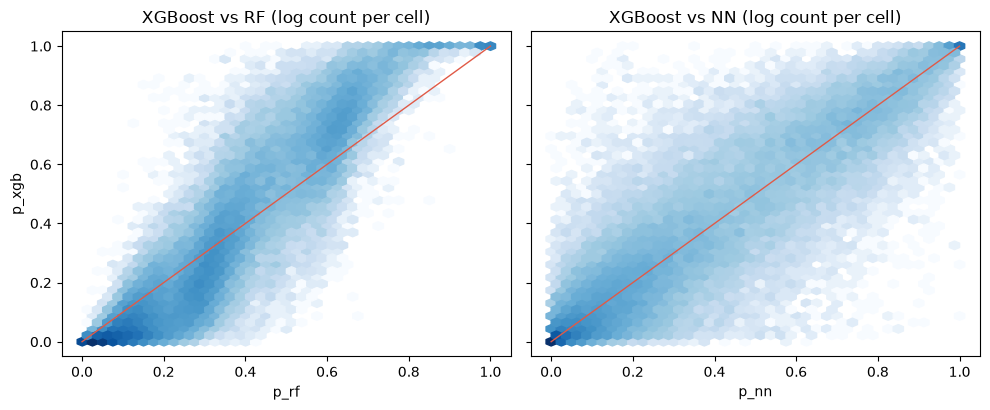

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, other in zip(axes, ['rf', 'nn']):
    ax.hexbin(p[other], p['xgb'], gridsize=40, bins='log', cmap='Blues')
    ax.plot([0, 1], [0, 1], color=palette[1], lw=1)
    ax.set_xlabel(f'p_{other}')
    ax.set_title(f'XGBoost vs {other.upper()} (log count per cell)')
axes[0].set_ylabel('p_xgb')
plt.tight_layout()
plt.show()

Left: the XGB–RF cloud bends into an S around the diagonal. RF is less confident at both ends (averaging many trees pulls probabilities towards the middle): 36.5% of bookings get p_xgb < 0.05 but only 17.6% get p_rf < 0.05, and 2.9% against 0.9% sit above 0.95. Much of their disagreement is about confidence rather than ranking, which AP ignores. Right: the XGB–NN cloud is wider and symmetric, so the NN's differences are noisier rather than systematic.

## 4. Three ensemble options, scored per outer fold

For outer fold *k* every option is scored on fold *k*'s rows only.

- **E1 simple average** `(p_xgb + p_rf) / 2`: nothing is chosen, so nothing can leak.
- **E2 weighted average** `w·p_xgb + (1−w)·p_rf`, with `w ∈ {0.3, …, 0.7}` chosen by the pooled AP
  of the **other four folds'** OOF rows, then applied to fold *k*.
- **E3 stacking**: logistic regression on `logit(p)` of XGB, RF, NN and DT, fitted on the other four
  folds' OOF rows and applied to fold *k*. **Exploratory only, not adoptable.** Those OOF values came
  from base models that were trained on fold *k*'s rows, so fold *k*'s labels reach the meta-model
  indirectly (rule B3). Removing that leak would need the base models refitted without fold *k*,
  which this task does not do.

In [7]:
def scores(y_true, proba):
    pred = proba >= 0.5
    return {'ap': average_precision_score(y_true, proba),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred), 'f1': f1_score(y_true, pred)}

ensembles = {
    'xgboost': oof.p_xgb.to_numpy(),                          # the reference, for pairing
    'E1_average': ((oof.p_xgb + oof.p_rf) / 2).to_numpy(),
}
{k: round(average_precision_score(y, v), 4) for k, v in ensembles.items()}

{'xgboost': 0.7642, 'E1_average': 0.7691}

Pooled over all 67,974 rows, the simple average lifts AP from 0.7642 to 0.7691 (+0.005). Pooled AP is only a first look; the stop/go test below uses the per-fold values.

In [8]:
weights = [0.3, 0.4, 0.5, 0.6, 0.7]
p_e2 = np.empty(len(oof))
w_rows = []
for k in range(5):
    fit, score = fold != k, fold == k
    # weight chosen on the other four folds only
    ap_by_w = {w: average_precision_score(y[fit], w * oof.p_xgb[fit] + (1 - w) * oof.p_rf[fit]) for w in weights}
    w_k = max(ap_by_w, key=ap_by_w.get)
    p_e2[score] = w_k * oof.p_xgb[score] + (1 - w_k) * oof.p_rf[score]
    w_rows.append({'outer_fold': k, 'chosen_w': w_k, **{f'ap_other4_w{w}': a for w, a in ap_by_w.items()}})

ensembles['E2_weighted'] = p_e2
w_table = pd.DataFrame(w_rows).set_index('outer_fold')
w_table.round(4)

,chosen_w,ap_other4_w0.3,ap_other4_w0.4,ap_other4_w0.5,ap_other4_w0.6,ap_other4_w0.7
outer_fold,,,,,,
0,0.5,0.7654,0.7669,0.7675,0.7674,0.7667
1,0.6,0.7645,0.7660,0.7667,0.7668,0.7663
2,0.6,0.7674,0.7690,0.7698,0.7699,0.7694
3,0.5,0.7678,0.7693,0.7700,0.7700,0.7694
4,0.5,0.7696,0.7710,0.7717,0.7716,0.7710


The weight chosen on the other four folds is 0.5 in folds 0, 3 and 4 and 0.6 in folds 1 and 2. The AP curve over `w` is very flat (0.5 and 0.6 differ by at most 0.0002), so E2 is in practice E1 with a slight lean towards XGBoost; tuning the weight buys nothing.

In [9]:
def logit(q):
    q = np.clip(q, 1e-6, 1 - 1e-6)
    return np.log(q / (1 - q))

Z = logit(oof[[f'p_{s}' for s in models]].to_numpy())
p_e3 = np.empty(len(oof))
coef_rows = []
for k in range(5):
    fit, score = fold != k, fold == k
    meta = LogisticRegression(max_iter=1000, random_state=42).fit(Z[fit], y[fit])
    p_e3[score] = meta.predict_proba(Z[score])[:, 1]
    coef_rows.append({'outer_fold': k, 'intercept': meta.intercept_[0],
                      **{f'coef_{s}': c for s, c in zip(models, meta.coef_[0])}})

ensembles['E3_stacking'] = p_e3
pd.DataFrame(coef_rows).set_index('outer_fold').round(3)

,intercept,coef_xgb,coef_rf,coef_nn,coef_dt
outer_fold,,,,,
0,0.138,0.482,0.472,0.146,0.016
1,0.131,0.465,0.466,0.149,0.028
2,0.124,0.501,0.427,0.157,0.014
3,0.132,0.507,0.443,0.141,0.021
4,0.137,0.496,0.481,0.151,0.010


The meta-model gives XGBoost and RF almost equal weight (≈0.43–0.51 each on the logit scale), the neural network about 0.15 and the decision tree almost nothing (≤0.03). The coefficients are stable across the five fits. Remember that these fits saw fold *k*'s labels indirectly, so E3's scores below are optimistic by construction.

## 5. Rule 9.1 against XGBoost

In [10]:
rows = []
for name, proba in ensembles.items():
    for k in range(5):
        s = fold == k
        rows.append({'option': name, 'outer_fold': str(k), **scores(y[s], proba[s]),
                     'w': w_table.loc[k, 'chosen_w'] if name == 'E2_weighted' else np.nan,
                     'n_eval': int(s.sum())})
per_fold = pd.DataFrame(rows)

ap = per_fold.pivot(index='outer_fold', columns='option', values='ap')[list(ensembles)]
# the reference AP per fold must be exactly what v2/08 saved
saved = pd.read_csv(results / 'xgboost.csv').query("outer_fold in ['0','1','2','3','4']")
assert np.allclose(ap['xgboost'].to_numpy(), saved['ap'].to_numpy())
ap.round(4)

option,xgboost,E1_average,E2_weighted,E3_stacking
outer_fold,,,,
0,0.7726,0.7759,0.7759,0.7779
1,0.7727,0.7790,0.7787,0.7800
2,0.7608,0.7666,0.7664,0.7667
3,0.7612,0.7657,0.7657,0.7672
4,0.7547,0.7591,0.7591,0.7611


XGBoost's per-fold AP matches `reports/results/v2/xgboost.csv` exactly (asserted). Every ensemble is above XGBoost in every fold, but only by 0.003–0.007.

In [11]:
bar = ap['xgboost'].std()          # ddof=1, the XGBoost outer-fold SD
gain = ap.sub(ap['xgboost'], axis=0)

rule = pd.DataFrame({
    'ap_mean': ap.mean(), 'ap_sd': ap.std(),
    'mean_paired_gain': gain.mean(), 'bar_xgb_sd': bar,
    'folds_better': gain.gt(0).sum(),
}).drop(index='xgboost')
rule['passes_9_1'] = (rule.mean_paired_gain > bar) & (rule.folds_better >= 4)
rule['adoptable'] = rule.index != 'E3_stacking'
print(f'bar = {bar:.4f}  (XGBoost outer-fold SD, ddof=1)')
rule.round(4)

bar = 0.0080  (XGBoost outer-fold SD, ddof=1)


,ap_mean,ap_sd,mean_paired_gain,bar_xgb_sd,folds_better,passes_9_1,adoptable
option,,,,,,,
E1_average,0.7693,0.0081,0.0049,0.008,5,False,True
E2_weighted,0.7692,0.0080,0.0048,0.008,5,False,True
E3_stacking,0.7706,0.0080,0.0062,0.008,5,False,False


**Reading:** rule 9.1 needs a mean paired gain above **0.0080** (the XGBoost fold SD) **and** at least 4 of 5 folds better. E1 gains **+0.0049** (5/5 folds) and E2 **+0.0048** (5/5): consistent, but only about 60% of the bar, so **both fail**. E3 gains +0.0062 (5/5) and also fails, even with its indirect leak helping it; it could not be adopted anyway. The gains are real in sign but smaller than the fold-to-fold noise, as the 0.94 residual correlation predicted.

In [12]:
at_05 = per_fold.groupby('option')[['precision', 'recall', 'f1']].agg(['mean', 'std']).loc[list(ensembles)]
at_05.round(4)

precision          recall              f1        
                 mean     std    mean     std    mean     std
option                                                       
xgboost        0.7271  0.0065  0.6279  0.0101  0.6739  0.0084
E1_average     0.7478  0.0094  0.5984  0.0076  0.6648  0.0077
E2_weighted    0.7459  0.0089  0.6008  0.0092  0.6655  0.0081
E3_stacking    0.7310  0.0068  0.6299  0.0078  0.6766  0.0064

At the untuned 0.5 threshold the averages trade recall for precision (E1: precision 0.748 vs 0.727, recall 0.598 vs 0.628) and end with a slightly lower F1 (0.665 vs 0.674). This is the RF effect seen in the hexbins: averaging pulls probabilities towards the middle, so fewer bookings cross 0.5. The threshold is chosen on cost in T3, so these numbers do not decide anything here.

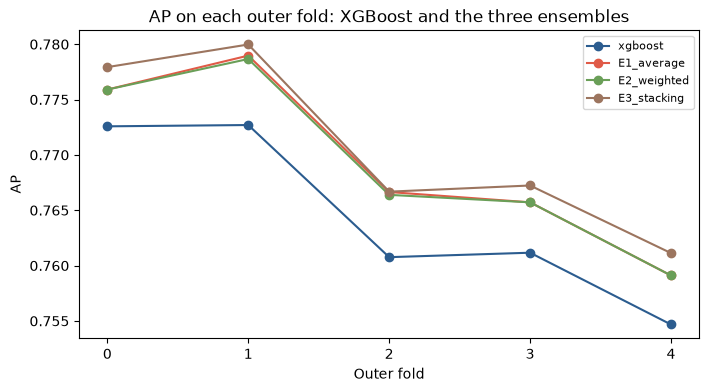

In [13]:
plt.figure(figsize=(8, 4))
for i, name in enumerate(ensembles):
    plt.plot(ap.index.astype(int), ap[name], marker='o', color=palette[i], label=name)
plt.xticks(range(5))
plt.xlabel('Outer fold')
plt.ylabel('AP')
plt.title('AP on each outer fold: XGBoost and the three ensembles')
plt.legend(fontsize=8)
plt.show()

The ensemble lines run parallel to XGBoost, a small constant step above it. The spread between folds (0.755–0.773 for XGBoost) is larger than the step, which is exactly what rule 9.1 guards against.

## 6. Decision

In [14]:
candidates = rule[rule.adoptable & rule.passes_9_1]
final_model = candidates.mean_paired_gain.idxmax() if len(candidates) else 'xgboost'
print('final model:', final_model)

final model: xgboost


**Decision: XGBoost stays the final model.** E1 (+0.0049) and E2 (+0.0048) are better in every fold but fail rule 9.1's 0.0080 bar; E3 (+0.0062) also fails and is not adoptable because of its indirect fold-*k* leak. A blend would also double the refit cost (RF takes ~191 s against ~6 s for XGBoost) and make the model harder to explain for about +0.005 AP. This is further evidence of an information ceiling in the 25 booking-time predictors: four different model families make largely the same mistakes. T3 uses the XGBoost OOF probabilities.

## 7. Save

In [15]:
summary = []
for name in ensembles:
    d = per_fold[per_fold.option == name]
    num = d[['ap', 'precision', 'recall', 'f1', 'w', 'n_eval']]
    summary += [{'option': name, 'outer_fold': 'mean', **num.mean().to_dict()},
                {'option': name, 'outer_fold': 'sd', **num.std().to_dict()}]   # ddof=1
table = pd.concat([per_fold, pd.DataFrame(summary)])
table['paired_gain_vs_xgb'] = table.apply(
    lambda r: gain.loc[r.outer_fold, r.option] if r.outer_fold in gain.index
    else (gain[r.option].mean() if r.outer_fold == 'mean' else gain[r.option].std()), axis=1)
table['can_replace_xgb'] = table.option.isin(['E1_average', 'E2_weighted'])
table['is_final'] = table.option == final_model
table = table.sort_values(['option', 'outer_fold'], key=lambda c: c.map(
    {n: i for i, n in enumerate(ensembles)}) if c.name == 'option' else c, kind='stable')
table.to_csv(results / 'ensemble.csv', index=False)

names = {'E1_average': 'ensemble_e1_average', 'E2_weighted': 'ensemble_e2_weighted',
         'E3_stacking': 'ensemble_e3_stacking'}
for name, file in names.items():
    out = oof[['row_id', 'outer_fold', 'is_canceled']].assign(proba=ensembles[name])
    out.to_csv(results / 'oof' / f'{file}.csv', index=False)

check = pd.read_csv(results / 'ensemble.csv', dtype={'outer_fold': str})
print(check.shape, sorted(p.name for p in (results / 'oof').glob('ensemble_*.csv')))
check.round(4)

(28, 11) ['ensemble_e1_average.csv', 'ensemble_e2_weighted.csv', 'ensemble_e3_stacking.csv']


,option,outer_fold,ap,precision,recall,f1,w,n_eval,paired_gain_vs_xgb,can_replace_xgb,is_final
0,xgboost,0,0.7726,0.7336,0.6357,0.6812,NaN,13595.0000,0.0000,False,True
1,xgboost,1,0.7727,0.7326,0.6392,0.6827,NaN,13594.0000,0.0000,False,True
2,xgboost,2,0.7608,0.7281,0.6225,0.6711,NaN,13595.0000,0.0000,False,True
3,xgboost,3,0.7612,0.7234,0.6283,0.6725,NaN,13595.0000,0.0000,False,True
4,xgboost,4,0.7547,0.7179,0.6140,0.6619,NaN,13595.0000,0.0000,False,True
5,xgboost,mean,0.7644,0.7271,0.6279,0.6739,NaN,13594.8000,0.0000,False,True
6,xgboost,sd,0.0080,0.0065,0.0101,0.0084,NaN,0.4472,0.0000,False,True
7,E1_average,0,0.7759,0.7591,0.6007,0.6707,NaN,13595.0000,0.0033,True,False
8,E1_average,1,0.7790,0.7519,0.6090,0.6729,NaN,13594.0000,0.0063,True,False
9,E1_average,2,0.7666,0.7503,0.5949,0.6636,NaN,13595.0000,0.0059,True,False


`ensemble.csv` holds one row per option and outer fold (XGBoost included as the paired reference),
then a `mean` and an `sd` row (ddof=1) per option. Each ensemble's OOF probabilities are saved with the
same columns as the base-model OOF files, so later stages could read them the same way.